In [1]:
import pyarrow.feather as feather
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from item_classifier import *
from plots import *

In [2]:
table = feather.read_table('../dataset/data_andre_fulfilled.feather', memory_map=True) 
df= table.to_pandas() 
df.head()

,item_id,store_id,date,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,...,promo_type_DISC,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE
0,27,6269,2021-01-23,8.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,27,6269,2021-01-24,14.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,27,6269,2021-01-25,8.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,27,6269,2021-01-26,5.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,27,6269,2021-01-27,8.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [3]:
df_indexed = df.copy()
df_indexed["date"] = pd.to_datetime(df_indexed["date"])
df_indexed = df_indexed.set_index("date").sort_index()
df_indexed.head()

,item_id,store_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,promo_type_DISC,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,6269,8.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-23,113613,6269,3.0,refrig dsrts,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-23,13108,6269,4.0,cream chs,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-23,53665,6269,1.0,sparkling seltzer mixer,pos subd grocery other,pos dept grocery,water/isotonics,0.0,0.0,0.0,...,0.0,0.0,1.0,0.1304,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-23,31242,6269,0.0,yogurt,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0


In [4]:
'''
# Classify all items
df_classified, summary = classify_items(
    df_indexed,
    seasonal_strength_threshold=0.3,    # Adjust based on your domain
    cv_threshold=0.5,                    # Adjust for intermittence detection
    initial_gap_fraction=0.2,            # 20% gap at start = new item
)

# Display summary
print("Label Distribution:")
print(summary['label_counts'])
print("\n" + "="*60)

df_classified.head()
'''


'\n# Classify all items\ndf_classified, summary = classify_items(\n    df_indexed,\n    seasonal_strength_threshold=0.3,    # Adjust based on your domain\n    cv_threshold=0.5,                    # Adjust for intermittence detection\n    initial_gap_fraction=0.2,            # 20% gap at start = new item\n)\n\n# Display summary\nprint("Label Distribution:")\nprint(summary[\'label_counts\'])\nprint("\n" + "="*60)\n\ndf_classified.head()\n'


## Classification Parameters Guide

The classifier uses three main parameters to categorize items:

### 1. `seasonal_strength_threshold` (default: 0.3)
- **What**: Strength of periodicity/seasonality in sales pattern (0-1 scale)
- **Higher values**: More strict seasonality detection
- **Lower values**: Easier to detect seasonal patterns
- **From document**: Items with sales/non-sales cycles that are regular and periodic

### 2. `cv_threshold` (default: 0.5)  
- **What**: Coefficient of Variation in cycle intervals
- **Higher values**: Allow more variability in intervals (more "erratic")
- **Lower values**: Stricter intermittence detection
- **From document**: Intermittent items have intervals that "don't share any common pattern"

### 3. `initial_gap_fraction` (default: 0.2)
- **What**: Fraction of zero-sales at the beginning (0-1 scale)
- **Higher values**: Allow longer initial gaps
- **Lower values**: Stricter new item detection
- **From document**: New items have "meaningful non-sales cycle at the beginning"

## Tuning Tips
- Start with defaults, then adjust based on your visualization results
- If too many items are "seasonal" → increase `seasonal_strength_threshold`
- If too many items are "intermittent" → increase `cv_threshold`
- If too many items are "new" → increase `initial_gap_fraction`


In [5]:
#plot_label_distribution(summary["label_counts"]);

In [6]:
df_classified, labels_df, summary = classify_items_adi_cv(df_indexed)


In [7]:
df_indexed.head()

,item_id,store_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,promo_type_DISC,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,6269,8.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-23,113613,6269,3.0,refrig dsrts,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-23,13108,6269,4.0,cream chs,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-23,53665,6269,1.0,sparkling seltzer mixer,pos subd grocery other,pos dept grocery,water/isotonics,0.0,0.0,0.0,...,0.0,0.0,1.0,0.1304,0.0,0.0,0.0,0.0,0.0,0.0
2021-01-23,31242,6269,0.0,yogurt,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0


In [8]:
df_classified

,item_id,store_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,item_label
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,27,6269,8.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,erratic
2021-01-23,113613,6269,3.0,refrig dsrts,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,lumpy
2021-01-23,13108,6269,4.0,cream chs,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,erratic
2021-01-23,53665,6269,1.0,sparkling seltzer mixer,pos subd grocery other,pos dept grocery,water/isotonics,0.0,0.0,0.0,...,0.0000,1.0,0.1304,0.0,0.0,0.0,0.0,0.0,0.0,erratic
2021-01-23,31242,6269,0.0,yogurt,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,lumpy
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-22,162819,6269,3.0,rte cereal,pos subd grocery other,pos dept grocery,breakfast,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,lumpy
2023-02-22,219,6269,4.0,milknplant based bevs,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,erratic
2023-02-22,219733,6269,3.0,rte cereal,pos subd grocery other,pos dept grocery,breakfast,0.0,0.0,0.0,...,0.0000,0.0,0.0000,0.0,0.0,1.0,0.0,0.0,0.0,lumpy



Detailed Classification Distribution:
Total items: 1427

Breakdown:
  erratic     :    905 items ( 63.4%)
  lumpy       :    452 items ( 31.7%)
  smooth      :     67 items (  4.7%)
  intermittent:      3 items (  0.2%)


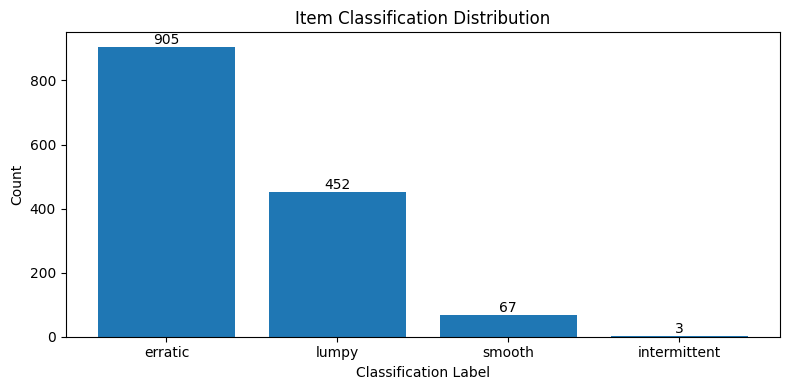

In [9]:
plot_label_distribution(summary['label_counts']);

Product ID: 151825
Date range: 2021-01-23 00:00:00 to 2023-02-22 00:00:00
Total records: 761
Non-zero sales: 550


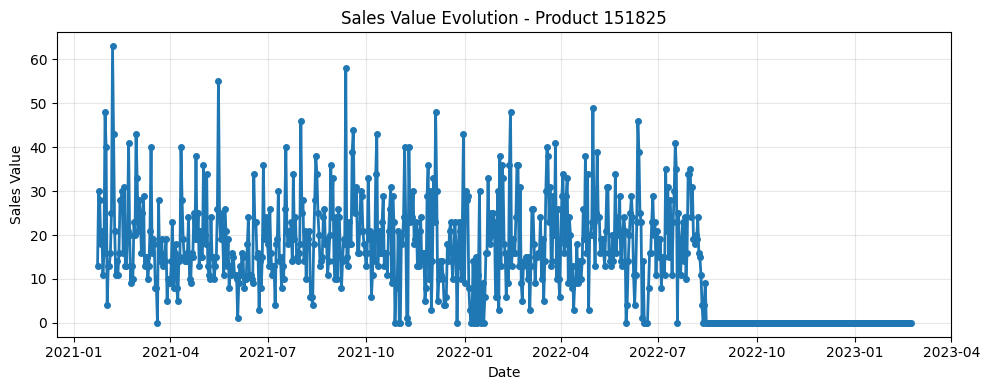

(<Axes: title={'center': 'Sales Value Evolution - Product 151825'}, xlabel='Date', ylabel='Sales Value'>,
           date  value
 0   2021-01-23   13.0
 1   2021-01-24   30.0
 2   2021-01-25   28.0
 3   2021-01-26   18.0
 4   2021-01-27   21.0
 ..         ...    ...
 756 2023-02-18    0.0
 757 2023-02-19    0.0
 758 2023-02-20    0.0
 759 2023-02-21    0.0
 760 2023-02-22    0.0
 
 [761 rows x 2 columns],
 {'product_id': 151825,
  'date_min': Timestamp('2021-01-23 00:00:00'),
  'date_max': Timestamp('2023-02-22 00:00:00'),
  'total_records': 761,
  'non_zero_sales': 550,
  'describe': count    761.000000
  mean      13.929041
  std       11.975752
  min        0.000000
  25%        0.000000
  50%       14.000000
  75%       21.000000
  max       63.000000
  Name: value, dtype: float64})

In [10]:
plot_product_value_evolution(df_indexed, selected_product=151825, date_col=None, value_col='value')


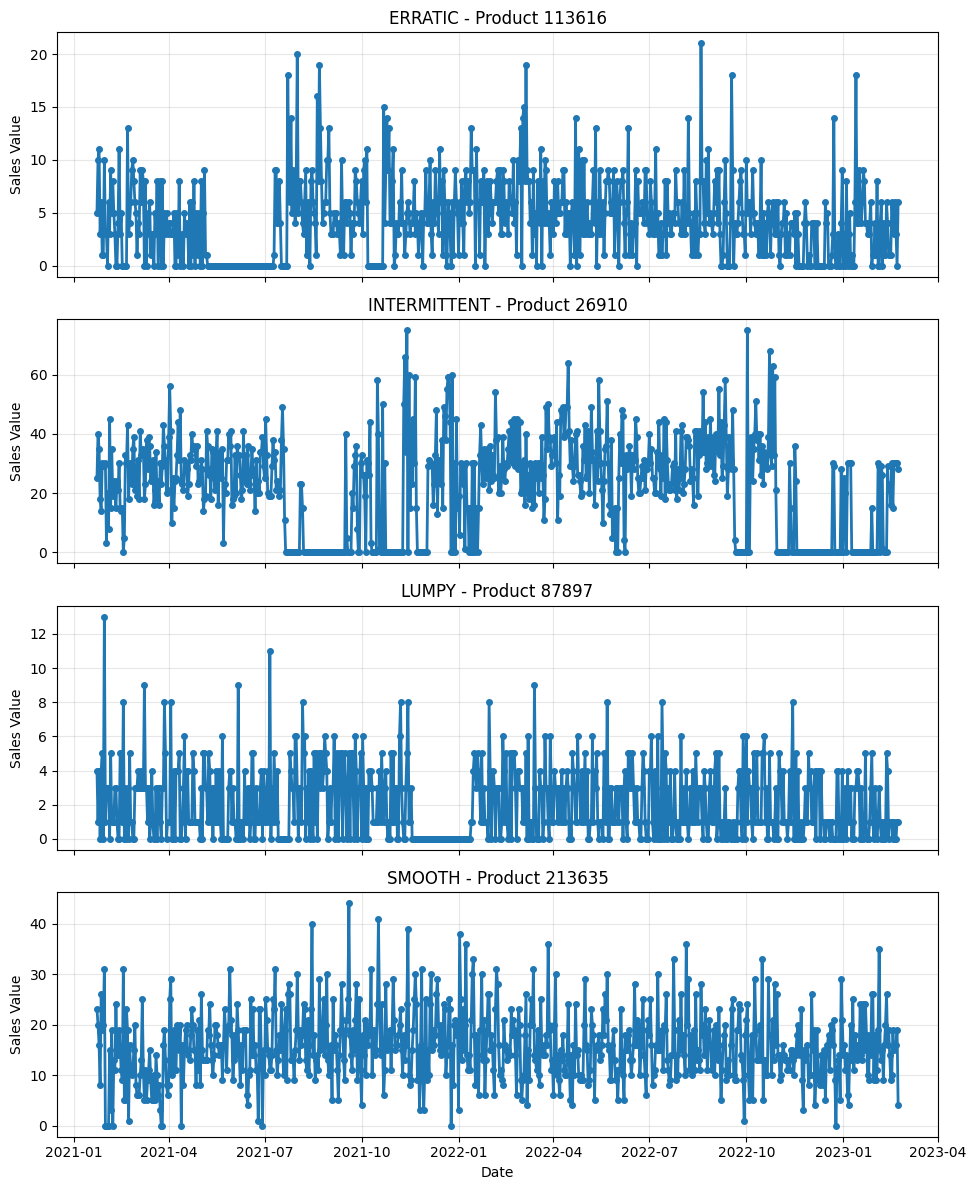

In [11]:
plot_random_sample_per_label(df_indexed, df_classified, date_col=None, seed=None);

In [12]:
df_classified[(df_classified['item_label']=='seasonal') | (df_classified['item_label']=='smooth')]

,item_id,store_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,promo_type_GAS,...,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE,item_label
date,,,,,,,,,,,,,,,,,,,,,
2021-01-23,113887,6269,13.0,yogurt,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,0.0,...,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,smooth
2021-01-23,959943,6269,8.0,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0.0,0.0,0.0,...,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,smooth
2021-01-23,9464,6269,9.0,dy non dy crm,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0,1.0,0.0178,0.0,0.0,0.0,0.0,0.0,0.0,smooth
2021-01-23,514230,6269,10.0,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0.0,0.0,0.0,...,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,smooth
2021-01-23,116,6269,16.0,dairy cream,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,smooth
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2023-02-22,26164,6269,11.0,sour cream,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,0.0,...,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,smooth
2023-02-22,1765,6269,18.0,dairy chs,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,0.0,...,0.0,0.0,0.0000,1.0,0.0,0.0,0.0,0.0,0.0,smooth
2023-02-22,921516,6269,10.0,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0.0,0.0,0.0,...,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0,smooth


In [13]:
def select_best_erratic_smooth(df, top_n=100, max_zero_rate=0.2, sales_col='value', item_col='item_id', label_col='item_label', labels=('erratic','smooth'), by='total_sales'):
    # filter erratic / smooth
    df_sub = df[df[label_col].isin(labels)].copy()

    # ensure numeric sales
    df_sub[sales_col] = pd.to_numeric(df_sub[sales_col], errors='coerce').fillna(0)

    # compute metrics per item
    agg = df_sub.groupby(item_col).agg(
        days_observed=('date', 'nunique'),
        total_sales=(sales_col, 'sum'),
        mean_sales=(sales_col, 'mean'),
        median_sales=(sales_col, 'median'),
        zeros=(sales_col, lambda x: (x==0).sum()),
        obs_count=(sales_col, 'count')
    ).reset_index()

    agg['zero_rate'] = agg['zeros'] / agg['obs_count']
    agg['nonzero_mean'] = agg.apply(lambda r: r['total_sales'] / max(1, r['obs_count'] - r['zeros']), axis=1)

    # filter by zero rate
    agg = agg[agg['zero_rate'] <= max_zero_rate]

    # choose sort key
    if by == 'total_sales':
        agg = agg.sort_values('total_sales', ascending=False)
    elif by == 'mean_sales':
        agg = agg.sort_values('mean_sales', ascending=False)
    elif by == 'nonzero_mean':
        agg = agg.sort_values('nonzero_mean', ascending=False)
    else:
        raise ValueError("by must be 'total_sales', 'mean_sales' or 'nonzero_mean'")

    # take top_n items and return original rows for those items
    top_items = agg.head(top_n)[item_col].tolist()
    return df_sub[df_sub[item_col].isin(top_items)].copy(), agg.loc[agg[item_col].isin(top_items)]

# Example usage:
# subset_rows, top_summary = select_best_erratic_smooth(df_classified, top_n=50, max_zero_rate=0.15)


In [14]:
# Show a few example products for each ADI-CV category
n_examples = 5
for cat in ["smooth", "erratic", "intermittent", "lumpy"]:
    items_in_cat = labels_df.loc[labels_df["label"] == cat].sort_values("total_periods", ascending=False)
    print(f"\n=== {cat.upper()} ({len(items_in_cat)} items) ===")
    display(items_in_cat.head(n_examples))



=== SMOOTH (67 items) ===


,item_id,label,adi,cv,non_zero_periods,total_periods
10,113887,smooth,1.071831,0.435624,710,761
985,213631,smooth,1.002635,0.321580,759,761
676,962444,smooth,1.056944,0.487799,720,761
684,324,smooth,1.087143,0.479208,700,761
689,57364,smooth,1.102899,0.486542,690,761



=== ERRATIC (905 items) ===


,item_id,label,adi,cv,non_zero_periods,total_periods
0,27,erratic,1.007947,0.503782,755,761
977,3720,erratic,1.104499,0.704915,689,761
937,962963,erratic,1.296422,0.707852,587,761
938,545599,erratic,1.020107,0.644747,746,761
940,266558,erratic,1.151286,0.604801,661,761



=== INTERMITTENT (3 items) ===


,item_id,label,adi,cv,non_zero_periods,total_periods
75,100472,intermittent,1.330420,0.487153,572,761
115,962210,intermittent,1.346903,0.477352,565,761
194,26910,intermittent,1.376130,0.376928,553,761



=== LUMPY (452 items) ===


,item_id,label,adi,cv,non_zero_periods,total_periods
1,113613,lumpy,1.381125,0.614323,551,761
917,153307,lumpy,1.474806,0.707728,516,761
1000,268649,lumpy,1.509921,0.669920,504,761
998,96792,lumpy,1.409259,0.755653,540,761
996,285024,lumpy,1.486328,0.636179,512,761


In [15]:
# Export item_id -> ADI/CV label (smooth / seasonal / intermittent / lumpy) to CSV
df_labels_adi_cv = (
    labels_df[["item_id", "label"]]
    .drop_duplicates(subset="item_id")
    .sort_values("item_id")
    .reset_index(drop=True)
)

out_path = "../dataset/df_labels_adi_cv.csv"
df_labels_adi_cv.to_csv(out_path, index=False)
print(f"Saved {len(df_labels_adi_cv)} rows -> {out_path}")
print(df_labels_adi_cv["label"].value_counts())
df_labels_adi_cv.head()


Saved 1427 rows -> ../dataset/df_labels_adi_cv.csv
label
erratic         905
lumpy           452
smooth           67
intermittent      3
Name: count, dtype: int64


,item_id,label
0,27,erratic
1,55,lumpy
2,71,erratic
3,116,smooth
4,128,erratic


In [16]:
 
# ── Export smooth-only products to feather ───────────────────────────────
smooth_ids = labels_df.loc[labels_df["label"] == "smooth", "item_id"].unique()
 
# Filter the full indexed dataframe to smooth items only, reset index so
# 'date' becomes a regular column again (feather doesn't support DatetimeIndex)
df_smooth = (
    df_indexed[df_indexed["item_id"].isin(smooth_ids)]
    .reset_index()          # moves 'date' back to a column
)
 
out_feather = "../dataset/data_smooth.feather"
df_smooth.to_feather(out_feather)
 
print(f"Smooth products : {len(smooth_ids)}")
print(f"Rows saved      : {len(df_smooth)}")
print(f"Saved to        : {out_feather}")
df_smooth.head()
 

Smooth products : 67
Rows saved      : 50987
Saved to        : ../dataset/data_smooth.feather


,date,item_id,store_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,...,promo_type_DISC,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE
0,2021-01-23,113887,6269,13.0,yogurt,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
1,2021-01-23,959943,6269,8.0,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
2,2021-01-23,9464,6269,9.0,dy non dy crm,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,...,0.0,0.0,1.0,0.0178,0.0,0.0,0.0,0.0,0.0,0.0
3,2021-01-23,514230,6269,10.0,carbonated sft drnks,pos subd grocery other,pos dept grocery,soda,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
4,2021-01-23,116,6269,16.0,dairy cream,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,...,0.0,0.0,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:

# ── Export smooth + erratic products to feather ───────────────────────────
smooth_erratic_ids = labels_df.loc[
    labels_df["label"].isin(["smooth", "erratic"]), "item_id"
].unique()

df_smooth_erratic = (
    df_indexed[df_indexed["item_id"].isin(smooth_erratic_ids)]
    .reset_index()
)

out_feather_se = "../dataset/data_smooth_erratic.feather"
df_smooth_erratic.to_feather(out_feather_se)

print(f"Smooth + Erratic products : {len(smooth_erratic_ids)}")
print(f"Rows saved                : {len(df_smooth_erratic)}")
print(f"Saved to                  : {out_feather_se}")
df_smooth_erratic.head()


Smooth + Erratic products : 972
Rows saved                : 739692
Saved to                  : ../dataset/data_smooth_erratic.feather


,date,item_id,store_id,value,cat_label,sdep_label,dep_label,dmn_label,promo_type_FRPG,promo_value_FRPG,...,promo_type_DISC,promo_value_DISC,promo_type_CIRC,promo_value_CIRC,promo_type_CIRE,promo_value_CIRE,promo_type_CLCP,promo_value_CLCP,promo_type_LFPE,promo_value_LFPE
0,2021-01-23,27,6269,8.0,refrigerated drnks,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,...,0.0,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
1,2021-01-23,13108,6269,4.0,cream chs,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,...,0.0,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
2,2021-01-23,53665,6269,1.0,sparkling seltzer mixer,pos subd grocery other,pos dept grocery,water/isotonics,0.0,0.0,...,0.0,0.0000,1.0,0.1304,0.0,0.0,0.0,0.0,0.0,0.0
3,2021-01-23,742,6269,4.0,refrigerated baked gds,pos subd dairy other,pos dept dairy,other dairy,0.0,0.0,...,0.0,0.0000,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0
4,2021-01-23,65948,6269,11.0,yogurt,pos subd dairy other,pos dept dairy,cheese/yogurt/orange juice,0.0,0.0,...,1.0,0.2603,0.0,0.0000,0.0,0.0,0.0,0.0,0.0,0.0


In [18]:
se_labels = labels_df[labels_df["label"].isin(["smooth", "erratic"])].copy()

In [19]:
# ── Sales distribution for smooth + erratic products ─────────────────────
se_labels = labels_df[labels_df["label"].isin(["smooth", "erratic"])].copy()

# Compute total & mean sales per item from the full time series
sales_agg = (
    df_indexed[df_indexed["item_id"].isin(se_labels["item_id"])]
    .groupby("item_id")["value"]
    .agg(total_sales="sum", mean_sales="mean", median_sales="median",
         nonzero_days=lambda x: (x > 0).sum())
    .reset_index()
)

se_stats = se_labels[["item_id", "label"]].merge(sales_agg, on="item_id")

# ── Filter Thresholds ─────────────────────────────────────────────────────
# Adjust these thresholds to exclude products above or below certain values
MIN_TOTAL_SALES = 0
MAX_TOTAL_SALES = float('inf')  # e.g., set to 10000 to exclude high sellers
MIN_MEAN_SALES = 0
MAX_MEAN_SALES = float('inf')   # e.g., set to 50 to exclude high mean sales

se_stats_filtered = se_stats[
    (se_stats["total_sales"] >= MIN_TOTAL_SALES) & 
    (se_stats["total_sales"] <= MAX_TOTAL_SALES) &
    (se_stats["mean_sales"] >= MIN_MEAN_SALES) &
    (se_stats["mean_sales"] <= MAX_MEAN_SALES)
].copy()

print(f"Original product count: {len(se_stats)}")
print(f"Filtered product count: {len(se_stats_filtered)}")
print(f"Excluded products: {len(se_stats) - len(se_stats_filtered)}\n")



# ── Top-selling products table (Filtered) ─────────────────────────────────
print("\nTop 30 products by total sales (after filtering):")
display(
    se_stats_filtered.sort_values("total_sales", ascending=False)
    .head(30)
    .reset_index(drop=True)
    .style.background_gradient(subset=["total_sales", "mean_sales"], cmap="YlOrRd")
)

Original product count: 972
Filtered product count: 972
Excluded products: 0


Top 30 products by total sales (after filtering):


,item_id,label,total_sales,mean_sales,median_sales,nonzero_days
0,110187,smooth,125015.000000,164.277267,158.000000,758
1,907969,smooth,88062.000000,115.718791,106.000000,759
2,911753,smooth,80682.000000,106.021025,99.000000,758
3,26008,smooth,65369.000000,85.898817,78.000000,759
4,213627,smooth,62801.000000,82.524310,81.000000,758
5,13544,erratic,60479.000000,79.473062,65.000000,752
6,213626,smooth,57211.000000,75.178712,73.000000,759
7,213628,smooth,55684.000000,73.172142,70.000000,759
8,213629,smooth,50972.000000,66.980289,64.000000,759
9,907967,smooth,40267.000000,52.913272,51.000000,750


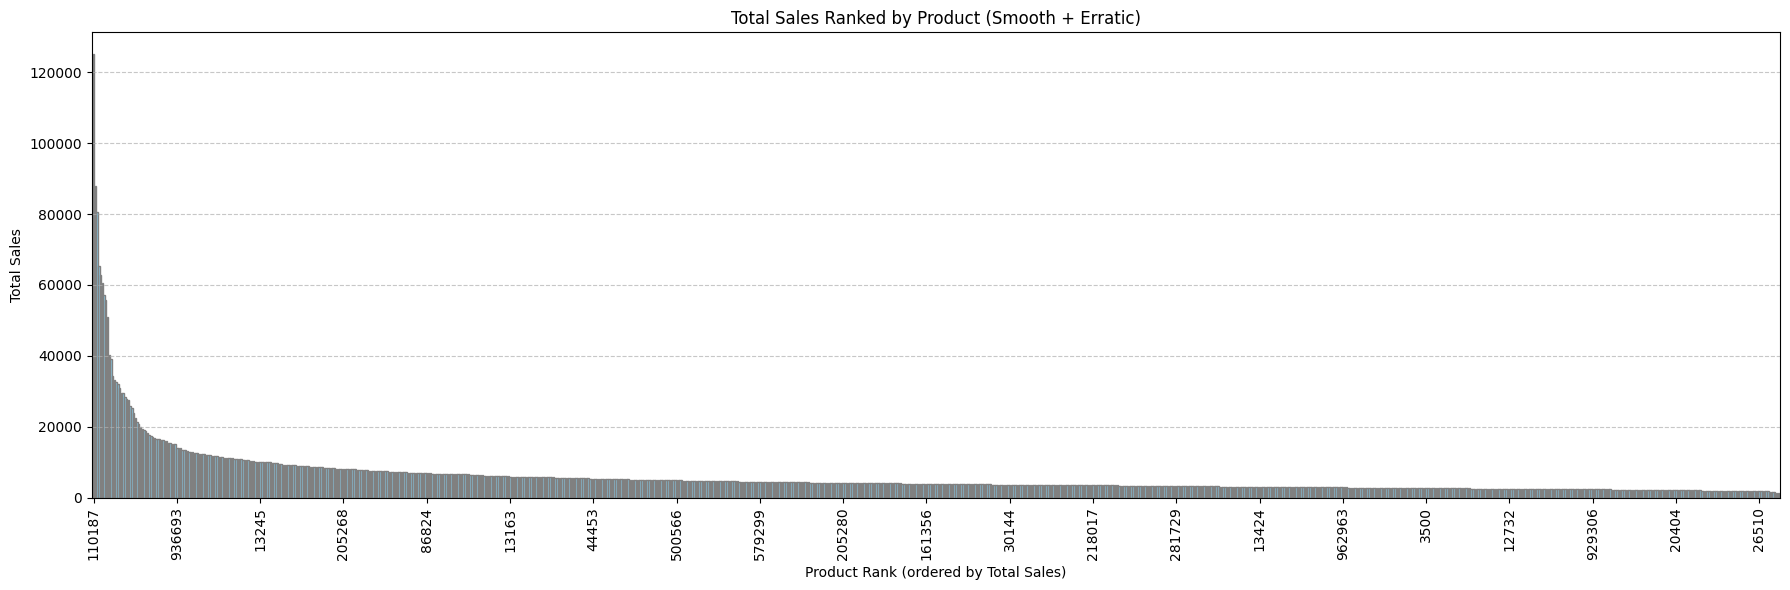

In [20]:
# ── Total Sales Ranked by Product ─────────────────────────────────────────

# Sort by total sales descending
ranked_stats = se_stats_filtered.sort_values("total_sales", ascending=False).reset_index(drop=True)

plt.figure(figsize=(18, 6))

# Plot the total sales as a bar chart
# If there are many products, we can just show the top N or use a line plot. 
# Here we'll show up to the top 100 as a bar chart, or all if there are fewer.
top_n = len(ranked_stats)

plt.bar(
    range(top_n), 
    ranked_stats.head(top_n)["total_sales"], 
    color='skyblue', 
    edgecolor='gray'
)

# Formatting the X axis
plt.title("Total Sales Ranked by Product (Smooth + Erratic)")
plt.xlabel("Product Rank (ordered by Total Sales)")
plt.ylabel("Total Sales")

# Add some grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# To view product_id on x-axis (works well if < 50 products, otherwise gets messy)
if top_n <= 50:
    plt.xticks(range(top_n), ranked_stats.head(top_n)["item_id"].astype(str), rotation=90)
else:
    # If too many products, we just label every Nth product or hide the labels to avoid overlapping
    plt.xticks(range(0, top_n, max(1, top_n//20)), 
               ranked_stats.head(top_n).iloc[::max(1, top_n//20)]["item_id"].astype(str), 
               rotation=90)

plt.xlim(-1, top_n)
plt.tight_layout()
plt.show()

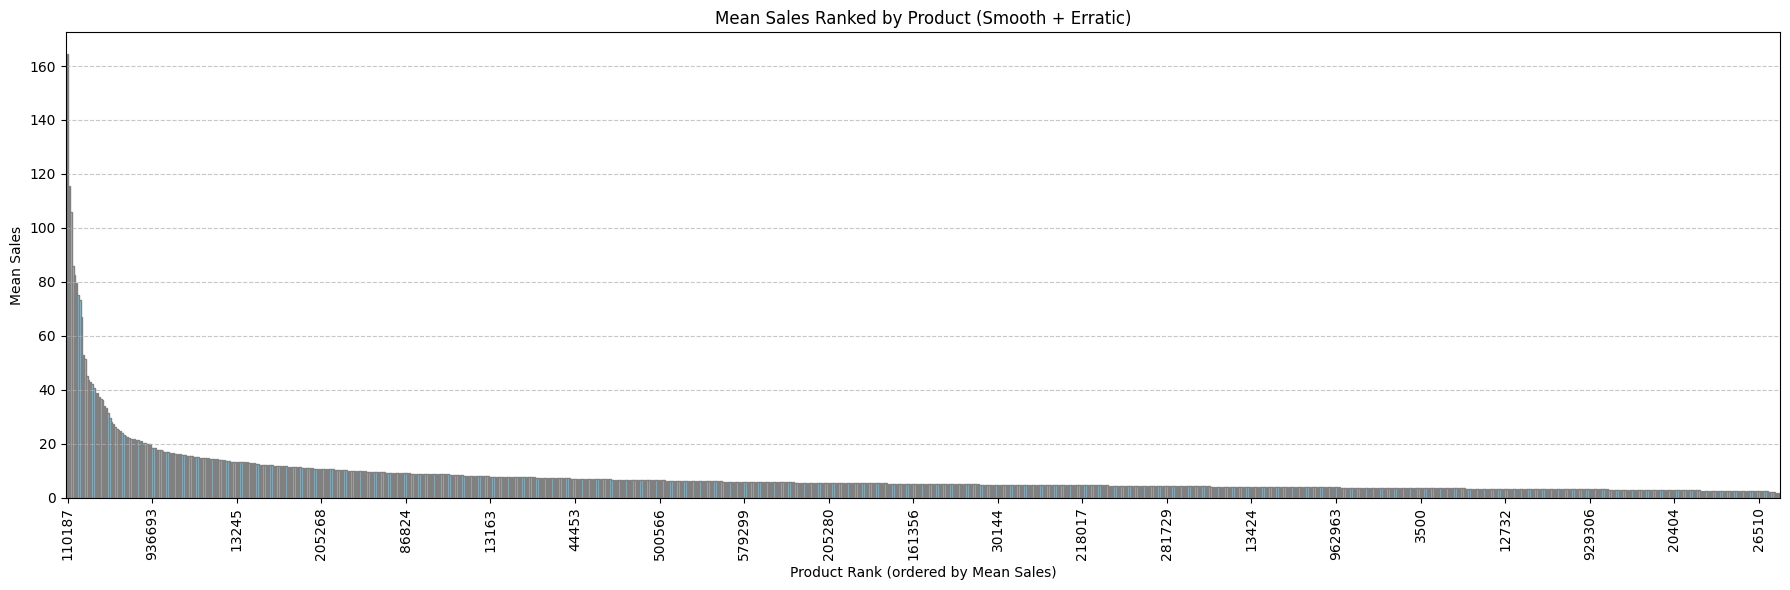

In [21]:
# ── Total Sales Ranked by Product ─────────────────────────────────────────

# Sort by mean sales descending
ranked_stats = se_stats_filtered.sort_values("mean_sales", ascending=False).reset_index(drop=True)

plt.figure(figsize=(18, 6))

# Plot the mean sales as a bar chart
# If there are many products, we can just show the top N or use a line plot. 
# Here we'll show up to the top 100 as a bar chart, or all if there are fewer.
top_n = len(ranked_stats)

plt.bar(
    range(top_n), 
    ranked_stats.head(top_n)["mean_sales"], 
    color='skyblue', 
    edgecolor='gray'
)

# Formatting the X axis
plt.title("Mean Sales Ranked by Product (Smooth + Erratic)")
plt.xlabel("Product Rank (ordered by Mean Sales)")
plt.ylabel("Mean Sales")

# Add some grid lines
plt.grid(axis='y', linestyle='--', alpha=0.7)

# To view product_id on x-axis (works well if < 50 products, otherwise gets messy)
if top_n <= 50:
    plt.xticks(range(top_n), ranked_stats.head(top_n)["item_id"].astype(str), rotation=90)
else:
    # If too many products, we just label every Nth product or hide the labels to avoid overlapping
    plt.xticks(range(0, top_n, max(1, top_n//20)), 
               ranked_stats.head(top_n).iloc[::max(1, top_n//20)]["item_id"].astype(str), 
               rotation=90)

plt.xlim(-1, top_n)
plt.tight_layout()
plt.show()

In [22]:
feather.write_feather(df_classified, f"../dataset/data_andre_classified.feather")

In [23]:
total_sales_threshold = 12500
mean_sales_threshold = 20

# Filter the previously computed se_stats based on these thresholds
top_products_total = se_stats[se_stats["total_sales"] >= total_sales_threshold].sort_values("total_sales", ascending=False)
top_products_mean = se_stats[se_stats["mean_sales"] >=  mean_sales_threshold].sort_values("mean_sales", ascending=False)

print(f"Products above {total_sales_threshold} total sales: {len(top_products_total)}")
display(
    top_products_total.head(40).reset_index(drop=True)
    .style.background_gradient(subset=["total_sales"], cmap="Blues")
    .set_caption("Top 30 products by Total Sales (above threshold)")
)

print(f"\nProducts above {mean_sales_threshold} mean sales: {len(top_products_mean)}")
display(
    top_products_mean.head(40).reset_index(drop=True)
    .style.background_gradient(subset=["mean_sales"], cmap="Greens")
    .set_caption("Top 30 products by Mean Sales (above threshold)")
)

Products above 12500 total sales: 61


,item_id,label,total_sales,mean_sales,median_sales,nonzero_days
0,110187,smooth,125015.000000,164.277267,158.000000,758
1,907969,smooth,88062.000000,115.718791,106.000000,759
2,911753,smooth,80682.000000,106.021025,99.000000,758
3,26008,smooth,65369.000000,85.898817,78.000000,759
4,213627,smooth,62801.000000,82.524310,81.000000,758
5,13544,erratic,60479.000000,79.473062,65.000000,752
6,213626,smooth,57211.000000,75.178712,73.000000,759
7,213628,smooth,55684.000000,73.172142,70.000000,759
8,213629,smooth,50972.000000,66.980289,64.000000,759
9,907967,smooth,40267.000000,52.913272,51.000000,750



Products above 20 mean sales: 45


,item_id,label,total_sales,mean_sales,median_sales,nonzero_days
0,110187,smooth,125015.000000,164.277267,158.000000,758
1,907969,smooth,88062.000000,115.718791,106.000000,759
2,911753,smooth,80682.000000,106.021025,99.000000,758
3,26008,smooth,65369.000000,85.898817,78.000000,759
4,213627,smooth,62801.000000,82.524310,81.000000,758
5,13544,erratic,60479.000000,79.473062,65.000000,752
6,213626,smooth,57211.000000,75.178712,73.000000,759
7,213628,smooth,55684.000000,73.172142,70.000000,759
8,213629,smooth,50972.000000,66.980289,64.000000,759
9,907967,smooth,40267.000000,52.913272,51.000000,750


In [24]:
df_top_products_total = df_indexed[df_indexed["item_id"].isin(top_products_total["item_id"])]
feather.write_feather(df_top_products_total, f"../dataset/top_{total_sales_threshold}.feather")

In [25]:
# ── Top Products Overall (Regardless of Label) ───────────────────────────────

# Compute total & mean sales per item for all products in the dataset
sales_agg_all = (
    df_indexed.groupby("item_id")["value"]
    .agg(total_sales="sum", mean_sales="mean", median_sales="median",
         nonzero_days=lambda x: (x > 0).sum())
    .reset_index()
)

# Merge with the labels_df to see which ADI/CV label they originally got
all_stats = labels_df[["item_id", "label"]].merge(sales_agg_all, on="item_id", how="right")

print("Top 50 products overall by Total Sales:")
display(
    all_stats.sort_values("total_sales", ascending=False)
    .head(50)
    .reset_index(drop=True)
    .style.background_gradient(subset=["total_sales", "mean_sales"], cmap="Purples")
)

Top 50 products overall by Total Sales:


,item_id,label,total_sales,mean_sales,median_sales,nonzero_days
0,110187,smooth,125015.000000,164.277267,158.000000,758
1,907969,smooth,88062.000000,115.718791,106.000000,759
2,911753,smooth,80682.000000,106.021025,99.000000,758
3,26008,smooth,65369.000000,85.898817,78.000000,759
4,213627,smooth,62801.000000,82.524310,81.000000,758
5,13544,erratic,60479.000000,79.473062,65.000000,752
6,213626,smooth,57211.000000,75.178712,73.000000,759
7,213628,smooth,55684.000000,73.172142,70.000000,759
8,213629,smooth,50972.000000,66.980289,64.000000,759
9,57457,lumpy,45982.000000,60.423127,55.000000,509
